In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import sys
sys.path.append('../')

# Charger les données
X_train = joblib.load('../data/X_train.pkl')
X_test = joblib.load('../data/X_test.pkl')

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print("Données chargées avec succès !")

X_train : (762157, 12)
X_test  : (190540, 12)
Données chargées avec succès !


In [2]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Entraîner Isolation Forest
print("Entraînement Isolation Forest...")
iso_forest = IsolationForest(
    contamination=0.05,  # on suppose 5% d'anomalies
    random_state=0,
    n_estimators=100
)

iso_forest.fit(X_train)
print("Isolation Forest entraîné ")

# Prédictions sur X_test
# -1 = anomalie, 1 = normal
iso_predictions = iso_forest.predict(X_test)

# Convertir : -1 → 1 (anomalie), 1 → 0 (normal)
iso_labels = (iso_predictions == -1).astype(int)

anomalies = iso_labels.sum()
print(f"\nAnomalies détectées : {anomalies} / {len(iso_labels)} ({anomalies/len(iso_labels)*100:.1f}%)")

# Sauvegarder
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
print("Modèle sauvegardé ")

Entraînement Isolation Forest...
Isolation Forest entraîné 

Anomalies détectées : 3353 / 190540 (1.8%)
Modèle sauvegardé 


In [3]:
import importlib
import utils.predictor
importlib.reload(utils.predictor)
from utils.predictor import predict

# Résultats Autoencoder
df_test = pd.DataFrame(X_test, columns=['n_flows', 'n_packets', 'n_bytes', 'n_dest_asn',
                'n_dest_ports', 'n_dest_ip', 'tcp_udp_ratio_packets',
                'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes',
                'avg_duration', 'avg_ttl'])

# Charger config autoencoder
import json
with open('../models/config.json', 'r') as f:
    config = json.load(f)

threshold = config['threshold']

import torch
import torch.nn as nn
import joblib

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(12, 8), nn.ReLU(), nn.Linear(8, 4), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 12))
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder()
model.load_state_dict(torch.load('../models/autoencoder.pth', map_location='cpu'))
model.eval()

X_test_tensor = torch.FloatTensor(X_test)
with torch.no_grad():
    X_pred = model(X_test_tensor)
    ae_errors = torch.mean((X_test_tensor - X_pred) ** 2, dim=1).numpy()

ae_labels = (ae_errors > threshold).astype(int)

# Tableau comparatif
print("=" * 50)
print(f"{'Métrique':<30} {'Autoencoder':>10} {'Iso Forest':>10}")
print("=" * 50)
print(f"{'Anomalies détectées':<30} {ae_labels.sum():>10} {iso_labels.sum():>10}")
print(f"{'Taux anomalies (%)':<30} {ae_labels.mean()*100:>10.1f} {iso_labels.mean()*100:>10.1f}")
print(f"{'Temps entraînement':<30} {'~6 min':>10} {'5.6 sec':>10}")
print(f"{'Nb paramètres':<30} {'288':>10} {'100 arbres':>10}")
print("=" * 50)

Métrique                       Autoencoder Iso Forest
Anomalies détectées                 27662       3353
Taux anomalies (%)                   14.5        1.8
Temps entraînement                 ~6 min    5.6 sec
Nb paramètres                         288 100 arbres


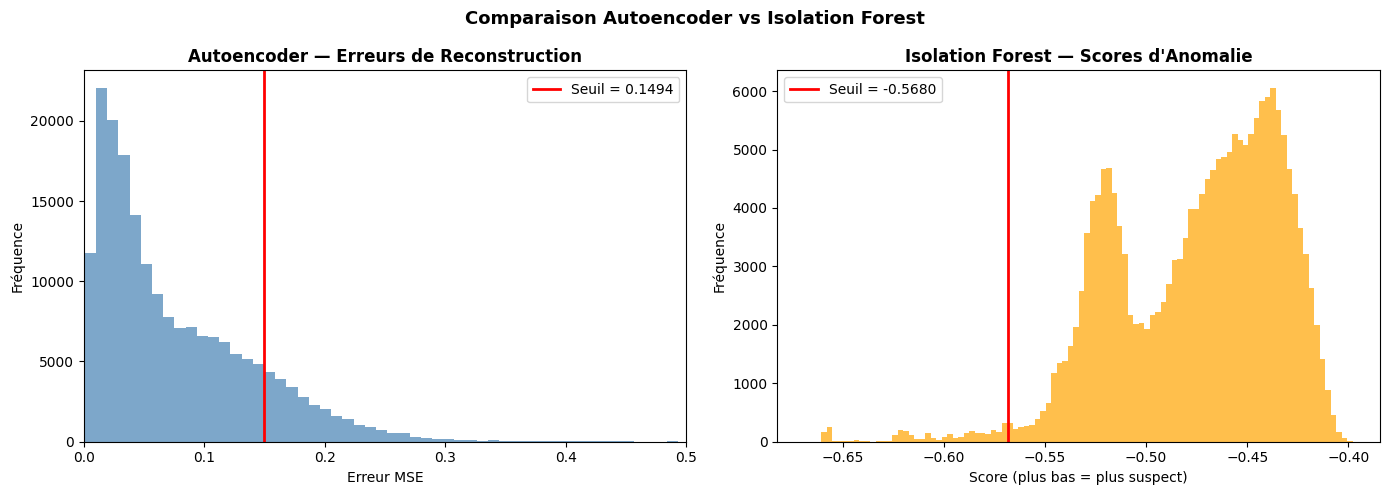

Graphique sauvegardé 


In [4]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Autoencoder
axes[0].hist(ae_errors, bins=100, color='steelblue', alpha=0.7)
axes[0].axvline(threshold, color='red', linewidth=2, label=f'Seuil = {threshold:.4f}')
axes[0].set_title('Autoencoder — Erreurs de Reconstruction', fontweight='bold')
axes[0].set_xlabel('Erreur MSE')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].set_xlim(0, 0.5)

# Isolation Forest
scores = iso_forest.score_samples(X_test)
axes[1].hist(scores, bins=100, color='orange', alpha=0.7)
axes[1].axvline(iso_forest.offset_, color='red', linewidth=2, label=f'Seuil = {iso_forest.offset_:.4f}')
axes[1].set_title('Isolation Forest — Scores d\'Anomalie', fontweight='bold')
axes[1].set_xlabel('Score (plus bas = plus suspect)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.suptitle('Comparaison Autoencoder vs Isolation Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notes/comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ")